In [7]:
%matplotlib notebook 

import os
import json
import yaml
import pickle
from pathlib import Path
from typing import List, Tuple, Optional, Union

import numpy as np
from scipy.ndimage import shift as ndshift
from skimage import transform, filters
from skimage.registration import phase_cross_correlation
from skimage.transform import AffineTransform, warp

import matplotlib.pyplot as plt
from matplotlib.widgets import Button

In [8]:
def wf_align(im_unaligned, animal, day, align_type='', master_align=None):
    """
    Align widefield images across days and animals
    
    Parameters:
    -----------
    im_unaligned : ndarray or list
        Unaligned images
    animal : str
        Animal ID, e.g. 'XX001'
    day : str or list
        Recording day 'yyyy-mm-dd' (or list if multiple days)
    align_type : str
        Type of alignment:
        - '' (default): apply saved day/animal transform
        - 'day_only': apply only day transform
        - 'animal_only': apply only animal transform
        - 'new_days': create new alignment within animal across days
        - 'new_animal': create new alignment from animal to master
        - 'create_master': create new master alignment reference
        - 'create_submaster': create sub-master (align to master)
    master_align : ndarray, optional
        Master template for alignment (used with 'new_animal')
    
    Returns:
    --------
    im_aligned : ndarray
        Aligned images
    im_tform : ndarray or dict
        Transformation matrix/matrices
    """
    
    # Set paths for saved alignments
    alignment_path = Path(f'/home/lsh/Data_attention/Transfer learning/DATA_linshu/{animal}/widefield_alignment')
    alignment_filename = alignment_path / f'wf_alignment_{animal}.pkl'
    
    # Create directories if they don't exist
    alignment_path.mkdir(exist_ok=True)

    
    if align_type == 'new_days':
        return _align_new_days(im_unaligned, animal, day, alignment_filename)
    
    elif align_type == 'new_animal':
        return _align_new_animal(im_unaligned, animal, alignment_filename, 
                                 alignment_path, master_align)
    
    elif align_type == 'create_master':
        return _create_master(im_unaligned, alignment_path)
    
    elif align_type == 'create_submaster':
        return _create_submaster(im_unaligned, alignment_path)
    
    else:
        # Apply saved alignments
        return _apply_alignments(im_unaligned, animal, day, align_type, 
                                alignment_filename)


if __name__ == "__main__":
    # Example 1: Apply saved alignment
    # im = np.load('my_image.npy')
    # im_aligned, tform = wf_align(im, 'XX001', '2024-01-15')
    
    # Example 2: Create new day alignments
    # images = [np.load(f'day{i}.npy') for i in range(5)]
    # days = ['2024-01-15', '2024-01-16', '2024-01-17', '2024-01-18', '2024-01-19']
    # im_aligned, tforms = wf_align(images, 'XX001', days, 'new_days')
    
    # Example 3: Align animal to master
    # animal_avg = np.load('animal_avg.npy')
    # master = np.load('master_vfs.npy')
    # im_aligned, tform = wf_align(animal_avg, 'XX001', None, 'new_animal', master)
    
    print("wf_align module loaded. See examples in __main__ section.")

wf_align module loaded. See examples in __main__ section.


In [ ]:
def _align_new_animal(im_unaligned, animal, alignment_filename, 
                     alignment_path, master_align):
    """Create across-animal alignment to master"""
    
    print(f"Creating animal alignment for {animal}...")
    
    # Load or use provided master
    if master_align is None and (im_unaligned is None or len(im_unaligned) == 0):
        # Load master VFS
        master_vfs_fn = alignment_path / 'master_vfs.npy'
        if not master_vfs_fn.exists():
            raise FileNotFoundError(f"Master VFS not found: {master_vfs_fn}")
        
        master_align = np.load(master_vfs_fn)
        
        # Load and align animal's VFS across days
        # (This would require loading retinotopy data)
        raise NotImplementedError("Automatic VFS loading not implemented")
        
    elif master_align is None:
        raise ValueError("Master alignment image must be provided")
    
    if im_unaligned is None:
        raise ValueError("Animal image must be provided")
    
    # Align animal image to master
    ref_size = master_align.shape
    
    print("Aligning to master...")
    shift, error, diffphase = phase_cross_correlation(
        master_align, im_unaligned, upsample_factor=10
    )
    
    # Create similarity transform (translation + rotation + scale)
    tform = transform.SimilarityTransform(translation=shift[::-1])
    
    im_aligned = transform.warp(
        im_unaligned.astype(float),
        tform.inverse,
        output_shape=ref_size,
        preserve_range=True
    )
    
    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Before alignment
    axes[0, 0].imshow(np.abs(master_align), cmap='RdBu_r', alpha=0.5)
    axes[0, 0].imshow(np.abs(im_unaligned), cmap='Greens', alpha=0.5)
    axes[0, 0].set_title('Unaligned')
    axes[0, 0].axis('off')
    
    # After alignment
    axes[0, 1].imshow(np.abs(master_align), cmap='RdBu_r', alpha=0.5)
    axes[0, 1].imshow(np.abs(im_aligned), cmap='Greens', alpha=0.5)
    axes[0, 1].set_title('Aligned')
    axes[0, 1].axis('off')
    
    # Master
    axes[1, 0].imshow(master_align, cmap='RdBu_r')
    axes[1, 0].set_title('Master')
    axes[1, 0].axis('off')
    
    # Aligned animal
    axes[1, 1].imshow(im_aligned, cmap='RdBu_r')
    axes[1, 1].set_title('Aligned Animal')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save if confirmed
    if not alignment_filename.exists():
        raise FileNotFoundError(f"No day alignments found for {animal}")
    
    confirm = input(f"Save animal alignment for {animal}? (y/n): ").strip().lower()
    
    if confirm == 'y':
        with open(alignment_filename, 'rb') as f:
            wf_tform = pickle.load(f)
        
        wf_tform['animal_tform'] = tform.params
        wf_tform['master_ref_size'] = ref_size
        
        with open(alignment_filename, 'wb') as f:
            pickle.dump(wf_tform, f)
        
        print(f"Saved animal alignment for {animal}.")
    else:
        print("Not saved.")
    
    return im_aligned, tform.params

In [6]:
def _create_master(im_unaligned, alignment_path):
    """Create master VFS from multiple animals"""
    
    raise RuntimeError("Really create new master? This should be run once only!")
    
    print("Creating new master VFS...")
    
    if not isinstance(im_unaligned, list):
        raise ValueError("Expected list of VFS images from multiple animals")
    
    # Ask about hemisphere symmetry
    print("Are left/right hemisphere colors same or opposite?")
    print("1: symmetric (same)")
    print("2: opposite")
    choice = input("Enter 1 or 2: ").strip()
    side_sign = 1 if choice == '1' else -1
    
    # Pad images to same size
    shapes = [img.shape for img in im_unaligned]
    max_h = max(s[0] for s in shapes)
    max_w = max(s[1] for s in shapes)
    
    vfs_padded = []
    for img in im_unaligned:
        pad_h = max_h - img.shape[0]
        pad_w = max_w - img.shape[1]
        padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='constant')
        vfs_padded.append(padded)
    
    vfs_unaligned_pad = np.stack(vfs_padded, axis=2)
    
    # Iterative alignment
    print("Iterating alignment of average VFS...")
    vfs_ref = np.nanmean(vfs_unaligned_pad, axis=2)
    ref_size = vfs_ref.shape
    
    n_loops = 5
    for loop in range(n_loops):
        vfs_aligned = np.zeros((ref_size[0], ref_size[1], len(im_unaligned)))
        
        for i, img in enumerate(im_unaligned):
            shift, _, _ = phase_cross_correlation(vfs_ref, img, upsample_factor=10)
            tform = transform.AffineTransform(translation=shift[::-1])
            
            aligned = transform.warp(
                img.astype(float),
                tform.inverse,
                output_shape=ref_size,
                preserve_range=True
            )
            vfs_aligned[:, :, i] = aligned
        
        vfs_ref = np.nanmean(vfs_aligned, axis=2)
        print(f"  Loop {loop+1}/{n_loops}")
    
    # Symmetrize
    print("Symmetrizing aligned average VFS...")
    n_loops = 15
    
    for loop in range(n_loops):
        ref_symm = (vfs_ref + side_sign * np.fliplr(vfs_ref)) / 2
        
        shift, _, _ = phase_cross_correlation(ref_symm, vfs_ref, upsample_factor=10)
        tform = transform.AffineTransform(translation=shift[::-1])
        
        vfs_ref = transform.warp(
            vfs_ref,
            tform.inverse,
            output_shape=ref_size,
            preserve_range=True
        )
        print(f"  Loop {loop+1}/{n_loops}")
    
    # Final symmetrization
    master_vfs = (vfs_ref + side_sign * np.fliplr(vfs_ref)) / 2
    
    # Visualize
    plt.figure(figsize=(8, 8))
    plt.imshow(master_vfs, cmap='RdBu_r')
    plt.clim(-1, 1)
    plt.axis('off')
    plt.title('Master VFS')
    plt.show()
    
    # Save
    confirm = input("Save new master VFS? (y/n): ").strip().lower()
    if confirm == 'y':
        save_path = alignment_path / 'master_vfs.npy'
        np.save(save_path, master_vfs)
        print(f"Saved master VFS to {save_path}")
    else:
        print("Not saved.")
    
    return master_vfs, None



In [7]:
def _create_submaster(im_unaligned, alignment_path):
    """Create submaster aligned to master VFS"""
    
    print("Creating submaster VFS...")
    
    if not isinstance(im_unaligned, list):
        raise ValueError("Expected list of VFS images")
    
    # Ask about symmetry
    print("Are left/right hemisphere colors same or opposite?")
    print("1: symmetric")
    print("2: opposite")
    choice = input("Enter 1 or 2: ").strip()
    side_sign = 1 if choice == '1' else -1
    
    # Similar process to create_master
    # (Shortened for brevity - follows same pattern)
    
    # ... iterative alignment and symmetrization ...
    
    # Load master and align submaster to it
    master_vfs_fn = alignment_path / 'master_vfs.npy'
    if not master_vfs_fn.exists():
        raise FileNotFoundError("Master VFS not found")
    
    master_vfs = np.load(master_vfs_fn)
    
    # Align submaster to master
    # ... (alignment code) ...
    
    print("Submaster creation not fully implemented")
    return None, None

In [8]:
def _apply_alignments(im_unaligned, animal, day, align_type, alignment_filename):
    """Apply saved alignments to data"""
    
    # Load alignment file
    if not alignment_filename.exists():
        raise FileNotFoundError(f"No alignments found for {animal}")
    
    with open(alignment_filename, 'rb') as f:
        wf_tform = pickle.load(f)
    
    # Find day index
    day_list = wf_tform['day']
    if day not in day_list and align_type != 'animal_only':
        raise ValueError(f"No alignment found for {animal} on {day}")
    
    curr_day_idx = day_list.index(day) if day in day_list else None
    
    # Determine transformation and output size
    if align_type == 'day_only':
        # Day alignment only
        curr_tform = wf_tform['day_tform'][curr_day_idx]
        ref_size = wf_tform['ref_size']
        
    elif align_type == 'animal_only':
        # Animal alignment only
        curr_tform = wf_tform['animal_tform']
        ref_size = wf_tform['master_ref_size']
        
    else:
        # Both day and animal
        curr_day_tform = wf_tform['day_tform'][curr_day_idx]
        
        if 'animal_tform' in wf_tform and wf_tform['animal_tform'] is not None:
            curr_animal_tform = wf_tform['animal_tform']
            # Combine transformations
            curr_tform = curr_day_tform @ curr_animal_tform
            ref_size = wf_tform['master_ref_size']
        else:
            print(f"Warning: {animal} {day}: No animal alignment")
            curr_tform = curr_day_tform
            ref_size = wf_tform['ref_size']
    
    # Apply transformation
    tform = transform.AffineTransform(matrix=curr_tform)
    im_aligned = transform.warp(
        im_unaligned.astype(float),
        tform.inverse,
        output_shape=ref_size,
        order=0,  # nearest neighbor
        preserve_range=True
    )
    
    # Cast back to original dtype
    im_aligned = im_aligned.astype(im_unaligned.dtype)
    
    return im_aligned, curr_tform


In [ ]:
def _visualize_alignment_stack(im_stack):
    """Visualize stack of aligned images"""
    
    n_images = im_stack.shape[2]
    
    # Show scrollable viewer (simplified)
    fig, ax = plt.subplots(figsize=(10, 10))
    
    current_slice = [0]  # Use list to modify in nested function
    
    im_display = ax.imshow(im_stack[:, :, 0], cmap='gray')
    ax.set_title(f'Image 1/{n_images}')
    ax.axis('off')
    
    vmin, vmax = np.percentile(im_stack, [1, 99])
    im_display.set_clim(vmin, vmax)
    
    def on_scroll(event):
        if event.button == 'up':
            current_slice[0] = (current_slice[0] + 1) % n_images
        else:
            current_slice[0] = (current_slice[0] - 1) % n_images
        
        im_display.set_data(im_stack[:, :, current_slice[0]])
        ax.set_title(f'Image {current_slice[0]+1}/{n_images}')
        fig.canvas.draw()
    
    fig.canvas.mpl_connect('scroll_event', on_scroll)
    plt.show
    


In [ ]:
def ask_save_alignment(im_aligned, alignment_filename, wf_tform):
    """Display first two aligned images + ask to save alignment"""
    
    # --- Step 1: Display alignment preview ---
    n_images = im_aligned.shape[2]
    fig, axes = plt.subplots(1, min(2, n_images), figsize=(10, 5))
    
    if n_images == 1:
        axes = [axes]
    
    axes[0].imshow(im_aligned[:, :, 0], cmap='gray')
    axes[0].set_title("Reference (Day 1)")
    axes[0].axis('off')

    if n_images > 1:
        axes[1].imshow(im_aligned[:, :, -1], cmap='gray')
        axes[1].set_title("Last Day (aligned)")
        axes[1].axis('off')
    
    plt.show()
    
    # --- Step 2: Ask user to save ---
    button_save = widgets.Button(description="Save alignment", button_style='success')
    button_discard = widgets.Button(description="Discard alignment", button_style='danger')
    output = widgets.Output()

    def save_clicked(b):
        with open(alignment_filename, 'wb') as f:
            pickle.dump(wf_tform, f)
        with output:
            print(f"✅ Saved alignment to {alignment_filename}")
        button_save.disabled = True
        button_discard.disabled = True

    def discard_clicked(b):
        with output:
            print("❎ Alignment not saved")
        button_save.disabled = True
        button_discard.disabled = True

    button_save.on_click(save_clicked)
    button_discard.on_click(discard_clicked)
    
    display(widgets.HBox([button_save, button_discard]), output)


In [ ]:
## _align_new_day new version 20251103 9:49
def _align_new_days(im_unaligned, animal, day, alignment_filename):
    """
    Complete interactive across-day alignment for animal with ipywidgets interface.
    
    Parameters:
    -----------
    im_unaligned : list or None
        List of images to align. If None, loads from config
    animal : str
        Animal ID
    day : list or None
        List of session IDs. If None, loads from config
    alignment_filename : str
        Path to save alignment file
        
    Returns:
    --------
    im_aligned : ndarray
        Aligned images (height, width, n_days)
    tform_matrix : list
        List of transformation matrices
    """
    print(f"Creating across-day alignments for {animal}...")

    # Step 1: Load images if None
    if im_unaligned is None or len(im_unaligned) == 0:
        im_unaligned = []
        config_path = f"/home/lsh/WF_GoNogo/config/{animal}_config.yaml"
        config = load_config(config_path)
        if day is None or len(day) == 0:
            day = config["sessions"]
        for session in config["sessions"]:
            process_path = config["paths"]["process"].format(
                base_dir=config["base_dir"], mouse_id=animal, session=session
            )
            fn = os.path.join(process_path, "imavg_blue.npy")
            im_unaligned.append(np.load(fn))

    if not isinstance(im_unaligned, list):
        im_unaligned = [im_unaligned]

    n_days = len(im_unaligned)
    print(f"  Loaded {n_days} images")

    # Step 2: Normalize images
    print("  Normalizing images for alignment...")
    im_unaligned_norm = []
    for img in im_unaligned:
        img_smooth = filters.gaussian(img, sigma=2)
        img_blur = filters.gaussian(img, sigma=10)
        img_norm = img_smooth / (img_blur + 1e-10)
        im_unaligned_norm.append(img_norm)

    # Step 3: Determine reference size
    shapes = [img.shape for img in im_unaligned]
    im_y_max = max(s[0] for s in shapes)
    im_x_max = max(s[1] for s in shapes)
    ref_size = (im_y_max, im_x_max)
    print(f"  Reference size: {ref_size}")

    # Step 4: Automatic rigid alignment
    print("  Rigid aligning images (with rotation)...")
    im_ref = im_unaligned_norm[0]
    im_aligned = np.zeros((ref_size[0], ref_size[1], n_days), dtype=np.float32)
    tform_matrix = []

    for idx, (img, img_norm) in enumerate(zip(im_unaligned, im_unaligned_norm)):
        print(f"    Day {idx + 1}/{n_days}...")
        
        tform = _register_rigid_multiscale(
            moving=img_norm,
            fixed=im_ref,
            pyramid_levels=3
        )
        
        curr_im_reg = warp(
            img.astype(float), 
            tform.inverse, 
            output_shape=ref_size, 
            preserve_range=True
        )
        
        im_aligned[:, :, idx] = curr_im_reg
        tform_matrix.append(tform.params)

    print("  Automatic alignment complete.")

    # Step 5: Interactive ipywidgets interface
    print("\n  Launching interactive interface...")
    
    # Set matplotlib to inline mode for ipywidgets
    import matplotlib
    matplotlib.use('module://matplotlib_inline.backend_inline')
    
    from ipywidgets import interact, IntSlider, FloatSlider, Button, HBox, VBox, Output, HTML
    from IPython.display import display, clear_output
    
    # Normalize for display
    vmin, vmax = np.nanpercentile(im_aligned, [1, 99])
    im_ref_display = np.clip((im_unaligned[0] - vmin) / (vmax - vmin), 0, 1)
    
    # State management
    state = {
        'current_day': 0,
        'blend_mode': 'magenta-green',
        'im_aligned': im_aligned.copy(),
        'tform_matrix': [m.copy() for m in tform_matrix],
        'manual_adjustments': {i: {'dx': 0, 'dy': 0, 'rot': 0} for i in range(n_days)},
        'im_ref_display': im_ref_display,
        'im_unaligned': im_unaligned,
        'ref_size': ref_size,
        'vmin': vmin,
        'vmax': vmax,
        'tform_matrix_orig': [m.copy() for m in tform_matrix]
    }
    
    def apply_transform(day_idx, dx, dy, rot):
        """Apply manual transformation to a specific day"""
        base_tform = AffineTransform(matrix=state['tform_matrix_orig'][day_idx])
        manual_tform = AffineTransform(
            rotation=np.deg2rad(rot),
            translation=[dx, dy]
        )
        combined = AffineTransform(matrix=manual_tform.params @ base_tform.params)
        
        aligned_img = warp(
            state['im_unaligned'][day_idx].astype(float),
            combined.inverse,
            output_shape=state['ref_size'],
            preserve_range=True
        )
        
        state['im_aligned'][:, :, day_idx] = aligned_img
        state['tform_matrix'][day_idx] = combined.params
        
        return aligned_img
    
    def create_blend_display(ref_img, aligned_img, mode='magenta-green'):
        """Create blended display with multiple visualization modes"""
        h, w = ref_img.shape
        
        if mode == 'magenta-green':
            # Magenta vs Green - better contrast
            blended = np.zeros((h, w, 3))
            blended[:, :, 1] = ref_img  # Green for reference
            blended[:, :, 0] = aligned_img  # Red for aligned
            blended[:, :, 2] = aligned_img  # Blue for aligned (makes magenta)
            blended = np.clip(blended * 1.5, 0, 1)
            
        elif mode == 'cyan-magenta':
            # Cyan vs Magenta
            blended = np.zeros((h, w, 3))
            blended[:, :, 1] = ref_img  # Green
            blended[:, :, 2] = ref_img  # Blue (makes cyan)
            blended[:, :, 0] = aligned_img  # Red
            blended[:, :, 2] += aligned_img  # Blue (makes magenta with red)
            blended = np.clip(blended * 0.8, 0, 1)
            
        elif mode == 'checkerboard':
            # Checkerboard pattern
            blended = np.zeros((h, w, 3))
            checker_size = 32
            checker = np.indices((h, w)).sum(axis=0) // checker_size % 2
            for i in range(3):
                blended[:, :, i] = np.where(checker, ref_img, aligned_img)
                
        elif mode == 'difference':
            # Difference map (highlights misalignment)
            diff = np.abs(ref_img - aligned_img)
            blended = np.zeros((h, w, 3))
            # Color code: blue=good alignment, red=misalignment
            blended[:, :, 2] = 1 - diff  # Blue where aligned
            blended[:, :, 0] = diff  # Red where different
            blended = np.clip(blended * 2, 0, 1)
            
        elif mode == 'side-by-side':
            # Side by side comparison
            blended = np.zeros((h, w*2, 3))
            for i in range(3):
                blended[:, :w, i] = ref_img
                blended[:, w:, i] = aligned_img
                
        elif mode == 'overlay':
            # Simple overlay with transparency
            blended = np.zeros((h, w, 3))
            avg = (ref_img + aligned_img) / 2
            for i in range(3):
                blended[:, :, i] = avg
            # Add edge detection for both
            from scipy import ndimage
            edges_ref = ndimage.sobel(ref_img)
            edges_aligned = ndimage.sobel(aligned_img)
            edges_ref = (edges_ref - edges_ref.min()) / (edges_ref.max() - edges_ref.min() + 1e-10)
            edges_aligned = (edges_aligned - edges_aligned.min()) / (edges_aligned.max() - edges_aligned.min() + 1e-10)
            blended[:, :, 1] = np.clip(blended[:, :, 1] + edges_ref * 0.5, 0, 1)  # Green edges for ref
            blended[:, :, 0] = np.clip(blended[:, :, 0] + edges_aligned * 0.5, 0, 1)  # Red edges for aligned
            
        return blended
    
    # Create output widget for displaying image
    output = Output()
    
    def update_display(day_idx, dx, dy, rot):
        """Update the display"""
        aligned_img = apply_transform(day_idx, dx, dy, rot)
        state['manual_adjustments'][day_idx] = {'dx': dx, 'dy': dy, 'rot': rot}
        
        # Normalize
        aligned_norm = np.clip((aligned_img - state['vmin']) / (state['vmax'] - state['vmin']), 0, 1)
        
        # Create blend with current mode
        blended = create_blend_display(state['im_ref_display'], aligned_norm, state['blend_mode'])
        
        # Display
        with output:
            clear_output(wait=True)
            
            # Determine figure size based on mode
            if state['blend_mode'] == 'side-by-side':
                figsize = (14, 7)
            else:
                figsize = (8, 8)
            
            fig, ax = plt.subplots(figsize=figsize, dpi=80)
            ax.imshow(blended)
            
            # Mode-specific titles
            mode_info = {
                'magenta-green': 'Green=Ref | Magenta=Aligned | White=Perfect',
                'cyan-magenta': 'Cyan=Ref | Magenta=Aligned | White=Perfect',
                'checkerboard': 'Checkerboard pattern (32px)',
                'difference': 'Blue=Aligned | Red=Misaligned',
                'side-by-side': 'Left=Ref | Right=Aligned',
                'overlay': 'Green edges=Ref | Red edges=Aligned'
            }
            
            ax.set_title(f'Day 1 vs Day {day_idx+1} | {mode_info[state["blend_mode"]]}\ndx={dx:.0f}, dy={dy:.0f}, rot={rot:.1f} deg', 
                        fontsize=11, fontweight='bold')
            ax.axis('off')
            plt.tight_layout()
            plt.show()
            plt.close(fig)
    
    # Create widgets
    day_slider = IntSlider(
        value=1,
        min=1,
        max=n_days,
        step=1,
        description='Day:',
        continuous_update=False,
        style={'description_width': '60px'}
    )
    
    dx_slider = FloatSlider(
        value=0,
        min=-300,
        max=300,
        step=1,
        description='Shift X:',
        continuous_update=True,
        style={'description_width': '60px'}
    )
    
    dy_slider = FloatSlider(
        value=0,
        min=-300,
        max=300,
        step=1,
        description='Shift Y:',
        continuous_update=True,
        style={'description_width': '60px'}
    )
    
    rot_slider = FloatSlider(
        value=0,
        min=-30,
        max=30,
        step=0.1,
        description='Rotate:',
        continuous_update=True,
        style={'description_width': '60px'}
    )
    
    from ipywidgets import Dropdown
    blend_dropdown = Dropdown(
        options=[
            ('Magenta-Green', 'magenta-green'),
            ('Cyan-Magenta', 'cyan-magenta'),
            ('Checkerboard', 'checkerboard'),
            ('Difference Map', 'difference'),
            ('Side-by-Side', 'side-by-side'),
            ('Edge Overlay', 'overlay')
        ],
        value='magenta-green',
        description='View Mode:',
        style={'description_width': '80px'}
    )
    
    reset_btn = Button(description='Reset', button_type='warning', layout={'width': '100px'})
    save_btn = Button(description='Save', button_type='success', layout={'width': '100px'})
    qc_btn = Button(description='QC Report', button_type='info', layout={'width': '100px'})
    
    status_html = HTML(value="<b>Status:</b> Ready")
    
    info_html = HTML(value="""
    <div style='background-color:#e8f4f8; padding:8px; border-radius:5px; margin:10px 0; font-size:11px;'>
        <b>View Modes:</b><br>
        • <b>Magenta-Green:</b> Best contrast, easy to see misalignment<br>
        • <b>Checkerboard:</b> Quick visual check<br>
        • <b>Difference:</b> Highlights errors (blue=good, red=bad)<br>
        • <b>Edge Overlay:</b> Shows structural alignment<br>
        • <b>Side-by-Side:</b> Direct comparison
    </div>
    """)
    
    # Interactive function
    def on_change(change):
        day_idx = day_slider.value - 1
        
        # Load saved adjustments when day changes
        if change['name'] == 'value' and change['owner'] is day_slider:
            adj = state['manual_adjustments'][day_idx]
            dx_slider.value = adj['dx']
            dy_slider.value = adj['dy']
            rot_slider.value = adj['rot']
        
        update_display(day_idx, dx_slider.value, dy_slider.value, rot_slider.value)
    
    def on_blend_change(change):
        """Handle blend mode change"""
        state['blend_mode'] = change['new']
        day_idx = day_slider.value - 1
        update_display(day_idx, dx_slider.value, dy_slider.value, rot_slider.value)
    
    def on_reset(b):
        day_idx = day_slider.value - 1
        state['manual_adjustments'][day_idx] = {'dx': 0, 'dy': 0, 'rot': 0}
        
        dx_slider.value = 0
        dy_slider.value = 0
        rot_slider.value = 0
        
        # Reset to original
        state['im_aligned'][:, :, day_idx] = warp(
            state['im_unaligned'][day_idx].astype(float),
            AffineTransform(matrix=state['tform_matrix_orig'][day_idx]).inverse,
            output_shape=state['ref_size'],
            preserve_range=True
        )
        state['tform_matrix'][day_idx] = state['tform_matrix_orig'][day_idx].copy()
        
        update_display(day_idx, 0, 0, 0)
        status_html.value = "<b>Status:</b> <span style='color:orange;'>Reset current day</span>"
    
    def on_qc(b):
        """Generate quality control report"""
        status_html.value = "<b>Status:</b> Generating QC report..."
        
        # Create QC figure with all days
        n_cols = min(4, n_days)
        n_rows = int(np.ceil(n_days / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), dpi=100)
        if n_days == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for day_idx in range(n_days):
            adj = state['manual_adjustments'][day_idx]
            aligned_img = apply_transform(day_idx, adj['dx'], adj['dy'], adj['rot'])
            aligned_norm = np.clip((aligned_img - state['vmin']) / (state['vmax'] - state['vmin']), 0, 1)
            
            # Use magenta-green blend for QC
            blended = create_blend_display(state['im_ref_display'], aligned_norm, 'magenta-green')
            
            axes[day_idx].imshow(blended)
            axes[day_idx].set_title(f'Day {day_idx+1}\ndx={adj["dx"]:.0f}, dy={adj["dy"]:.0f}, rot={adj["rot"]:.1f}°', 
                                   fontsize=9)
            axes[day_idx].axis('off')
        
        # Hide extra subplots
        for idx in range(n_days, len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle(f'Alignment QC Report - {animal}\nGreen=Reference | Magenta=Aligned | White=Perfect', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        plt.close(fig)
        
        status_html.value = "<b>Status:</b> QC report generated"
        
        # Also create an interactive flipbook version
        print("\n" + "="*60)
        print("Creating interactive flipbook...")
        print("="*60)
        
        def show_qc_day(day_idx):
            """Show QC for a single day"""
            adj = state['manual_adjustments'][day_idx]
            aligned_img = apply_transform(day_idx, adj['dx'], adj['dy'], adj['rot'])
            aligned_norm = np.clip((aligned_img - state['vmin']) / (state['vmax'] - state['vmin']), 0, 1)
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=100)
            
            # Magenta-green blend
            blend1 = create_blend_display(state['im_ref_display'], aligned_norm, 'magenta-green')
            axes[0].imshow(blend1)
            axes[0].set_title('Magenta-Green Overlay', fontsize=12, fontweight='bold')
            axes[0].axis('off')
            
            # Difference map
            blend2 = create_blend_display(state['im_ref_display'], aligned_norm, 'difference')
            axes[1].imshow(blend2)
            axes[1].set_title('Difference Map (Blue=Good)', fontsize=12, fontweight='bold')
            axes[1].axis('off')
            
            # Checkerboard
            blend3 = create_blend_display(state['im_ref_display'], aligned_norm, 'checkerboard')
            axes[2].imshow(blend3)
            axes[2].set_title('Checkerboard Pattern', fontsize=12, fontweight='bold')
            axes[2].axis('off')
            
            fig.suptitle(f'Day {day_idx+1} QC | dx={adj["dx"]:.0f}, dy={adj["dy"]:.0f}, rot={adj["rot"]:.1f}°',
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            plt.close(fig)
        
        # Create interactive flipbook
        from ipywidgets import interact
        interact(show_qc_day, day_idx=IntSlider(min=0, max=n_days-1, value=0, description='QC Day:'))
    
    def on_save(b):
        """Save and close"""
        wf_tform = {
            'animal': animal,
            'day': day if isinstance(day, list) else [day],
            'day_tform': state['tform_matrix'],
            'ref_size': state['ref_size'],
            'manual_adjustments': state['manual_adjustments']
        }
        
        Path(alignment_filename).parent.mkdir(parents=True, exist_ok=True)
        with open(alignment_filename, 'wb') as f:
            pickle.dump(wf_tform, f)
        
        status_html.value = f"<b>Status:</b> <span style='color:green;'>Saved to {alignment_filename}</span>"
        print(f"\n✅ Saved alignment for {animal} to {alignment_filename}")
    
    # Connect callbacks
    day_slider.observe(on_change, names='value')
    dx_slider.observe(on_change, names='value')
    dy_slider.observe(on_change, names='value')
    rot_slider.observe(on_change, names='value')
    blend_dropdown.observe(on_blend_change, names='value')
    reset_btn.on_click(on_reset)
    save_btn.on_click(on_save)
    qc_btn.on_click(on_qc)
    
    # Initial display
    update_display(0, 0, 0, 0)
    
    # Layout
    controls = VBox([
        HTML(value=f"<h2>Image Alignment - {animal}</h2>"),
        info_html,
        day_slider,
        blend_dropdown,
        dx_slider,
        dy_slider,
        rot_slider,
        HBox([reset_btn, save_btn, qc_btn]),
        status_html
    ])
    
    ui = HBox([output, controls])
    display(ui)
    
    print("\n✅ Interactive interface loaded!")
    
    return state['im_aligned'], state['tform_matrix']

Creating across-day alignments for A095...
  Loaded 4 images
  Normalizing images for alignment...
  Reference size: (512, 512)
  Rigid aligning images (with rotation)...
    Day 1/4...
    Day 2/4...
    Day 3/4...
    Day 4/4...
  Automatic alignment complete.

  Launching interactive interface...



✅ Interactive interface loaded!


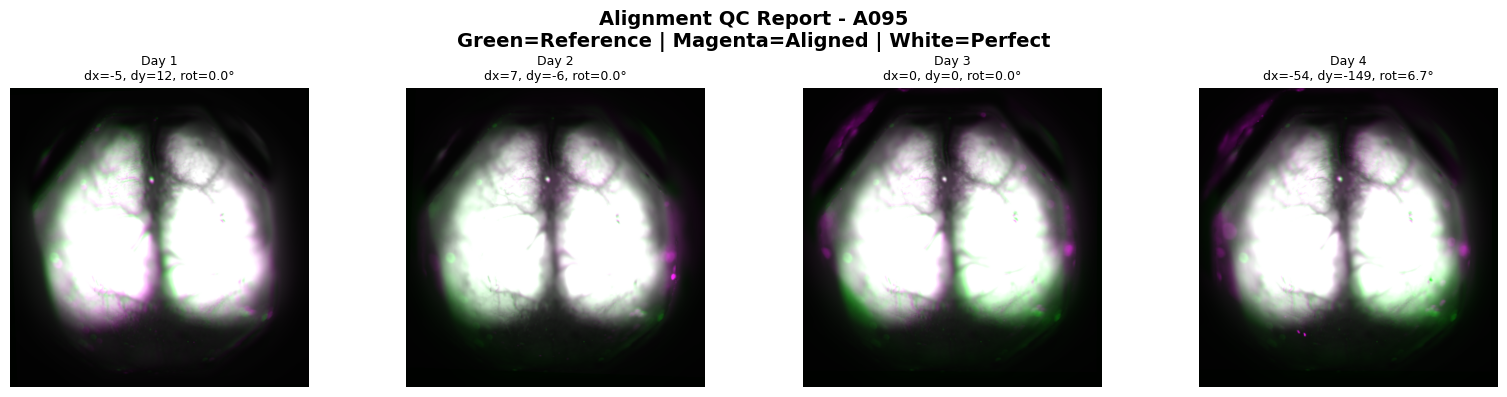

interactive(children=(IntSlider(value=0, description='QC Day:', max=3), Output()), _dom_classes=('widget-inter…

In [17]:
im_aligned, tforms = wf_align([], 'A095', [], 'new_days')

### Helper Functions

In [14]:
def _register_rigid_multiscale(moving, fixed, pyramid_levels=5):
    """
    Register images using multi-scale pyramid with rigid transformation
    (translation + rotation)
    
    This provides much better alignment than simple translation
    """
    
    # Build image pyramids
    moving_pyramid = _build_gaussian_pyramid(moving, pyramid_levels)
    fixed_pyramid = _build_gaussian_pyramid(fixed, pyramid_levels)
    
    # Initialize with identity transform
    best_rotation = 0
    best_translation = np.array([0.0, 0.0])
    
    # Process from coarse to fine
    for level in range(pyramid_levels - 1, -1, -1):
        moving_level = moving_pyramid[level]
        fixed_level = fixed_pyramid[level]
        scale_factor = 2 ** level
        
        # 1. Estimate translation using phase correlation
        shift, _, _ = phase_cross_correlation(
            fixed_level, moving_level, upsample_factor=30
        )
        
        # Scale up translation for this pyramid level
        scaled_translation = shift[::-1] * scale_factor + best_translation
        
        # 2. Estimate rotation by trying different angles
        best_rotation = _estimate_rotation_exhaustive(
            moving_level, fixed_level, 
            shift, best_rotation,
            angle_range=8 if level == pyramid_levels-1 else 5,
            angle_step=1 if level == pyramid_levels-1 else 0.5
        )
        
        # 3. Refine both translation and rotation
        best_rotation, best_translation = _refine_rigid_transform(
            moving_level, fixed_level,
            best_rotation, scaled_translation / scale_factor,
            max_iterations=20
        )
        
        # Scale translation for next level
        best_translation = best_translation * scale_factor
    
    # Create final transformation
    final_tform = AffineTransform(
        rotation=best_rotation,
        translation=best_translation
    )
    
    return final_tform

def _build_gaussian_pyramid(image, levels):
    """Build Gaussian pyramid for multi-scale registration"""
    pyramid = [image]
    for i in range(levels - 1):
        downsampled = filters.gaussian(pyramid[-1], sigma=1.0)
        downsampled = downsampled[::2, ::2]
        pyramid.append(downsampled)
    return pyramid


def _estimate_rotation_exhaustive(moving, fixed, shift, initial_rotation=0, 
                                  angle_range=10, angle_step=1):
    """
    Estimate rotation angle by exhaustive search
    Uses normalized cross-correlation as similarity metric
    """
    
    # Apply initial translation
    tform_shift = AffineTransform(translation=shift[::-1])
    moving_shifted = warp(moving, tform_shift.inverse, preserve_range=True)
    
    # Search around initial rotation
    angles = np.arange(
        initial_rotation - np.deg2rad(angle_range),
        initial_rotation + np.deg2rad(angle_range),
        np.deg2rad(angle_step)
    )
    
    best_correlation = -np.inf
    best_angle = initial_rotation
    
    for angle in angles:
        # Apply rotation
        tform_rot = AffineTransform(rotation=angle)
        moving_rotated = warp(moving_shifted, tform_rot.inverse, preserve_range=True)
        
        # Compute correlation in center region (avoid edges)
        h, w = moving_rotated.shape
        margin = min(h, w) // 10
        center_moving = moving_rotated[margin:-margin, margin:-margin]
        center_fixed = fixed[margin:-margin, margin:-margin]
        
        # Normalized cross-correlation
        correlation = np.corrcoef(center_moving.ravel(), center_fixed.ravel())[0, 1]
        
        if correlation > best_correlation:
            best_correlation = correlation
            best_angle = angle
    
    return best_angle


def _refine_rigid_transform(moving, fixed, rotation, translation, max_iterations=20):
    """
    Refine rigid transformation using gradient descent
    """
    
    current_rot = rotation
    current_trans = translation.copy()
    step_size = 0.1
    
    for iteration in range(max_iterations):
        # Compute current error
        tform = AffineTransform(rotation=current_rot, translation=current_trans)
        moving_warped = warp(moving, tform.inverse, preserve_range=True)
        current_error = np.mean((moving_warped - fixed) ** 2)
        
        # Try small perturbations
        delta_rot = np.deg2rad(0.5)
        delta_trans = 0.5
        
        # Gradient for rotation
        tform_rot_plus = AffineTransform(rotation=current_rot + delta_rot, translation=current_trans)
        moving_rot_plus = warp(moving, tform_rot_plus.inverse, preserve_range=True)
        error_rot_plus = np.mean((moving_rot_plus - fixed) ** 2)
        grad_rot = (error_rot_plus - current_error) / delta_rot
        
        # Gradient for translation x
        tform_tx_plus = AffineTransform(rotation=current_rot, translation=current_trans + [delta_trans, 0])
        moving_tx_plus = warp(moving, tform_tx_plus.inverse, preserve_range=True)
        error_tx_plus = np.mean((moving_tx_plus - fixed) ** 2)
        grad_tx = (error_tx_plus - current_error) / delta_trans
        
        # Gradient for translation y
        tform_ty_plus = AffineTransform(rotation=current_rot, translation=current_trans + [0, delta_trans])
        moving_ty_plus = warp(moving, tform_ty_plus.inverse, preserve_range=True)
        error_ty_plus = np.mean((moving_ty_plus - fixed) ** 2)
        grad_ty = (error_ty_plus - current_error) / delta_trans
        
        # Update parameters
        current_rot -= step_size * grad_rot
        current_trans[0] -= step_size * grad_tx
        current_trans[1] -= step_size * grad_ty
        
        # Reduce step size
        step_size *= 0.95
        
        # Stop if gradient is small
        grad_magnitude = np.sqrt(grad_rot**2 + grad_tx**2 + grad_ty**2)
        if grad_magnitude < 1e-6:
            break
    
    return current_rot, current_trans

In [18]:
def load_config(config_path):
    """load the YAML config"""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config